<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Project_1Stock_Market_EDA_1970_2018_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Historical Stock Prices (1970-2018) - Exploratory Data Analysis

**Objective:** clean and explore daily stock price data across decades, merge company sector information, create decade-level visualizations, and propose hypotheses for deeper financial analysis.

**Dataset files required:**
- `historical_stocks.csv`
- `historical_stock_prices.csv`

## 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)

## 2. Load Dataset Paths
Update these paths if your files are stored in a different folder.

In [25]:
stocks_path = "/content/drive/MyDrive/Willis_doc/historical_stocks.csv"
prices_path = "/content/drive/MyDrive/Willis_doc/historical_stock_prices.csv"

stocks = pd.read_csv(stocks_path)
prices = pd.read_csv(prices_path)

print("Stocks shape:", stocks.shape)
print("Prices shape:", prices.shape)

stocks.head()

Stocks shape: (6460, 5)
Prices shape: (20973889, 8)


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 3. Data Understanding
The price file is large, so this notebook first inspects a sample and then uses chunk processing for scalable EDA.

In [36]:
# Inspect a manageable sample first
prices_sample = pd.read_csv(prices_path, nrows=200_000, parse_dates=['date'])

print('Price sample shape:', prices_sample.shape)
display(prices_sample.head())

print('\nData types:')
display(prices_sample.dtypes)

print('\nDate range in sample:')
print(prices_sample['date'].min(), 'to', prices_sample['date'].max())

Price sample shape: (200000, 8)


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14



Data types:


,0
ticker,object
open,float64
close,float64
adj_close,float64
low,float64
high,float64
volume,int64
date,datetime64[ns]



Date range in sample:
1973-05-03 00:00:00 to 2018-08-24 00:00:00


## 4. Data Cleaning Strategy
The cleaning plan is: standardize column names, convert dates, check missing values, remove duplicates, and handle missing numerical values using median imputation when needed.

In [27]:
# Standardize column names
stocks.columns = stocks.columns.str.lower().str.strip()
prices_sample.columns = prices_sample.columns.str.lower().str.strip()

# Missing values in the sample
print('Missing values in stock metadata:')
display(stocks.isna().sum())

print('Missing values in price sample:')
display(prices_sample.isna().sum())

# Duplicate check in sample
print('Duplicate rows in stocks:', stocks.duplicated().sum())
print('Duplicate rows in price sample:', prices_sample.duplicated().sum())

# Clean sample for quick visual checks
prices_sample = prices_sample.drop_duplicates()
prices_sample['date'] = pd.to_datetime(prices_sample['date'], errors='coerce')
prices_sample = prices_sample.dropna(subset=['date'])

numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'adj_close']
for col in numeric_cols:
    prices_sample[col] = prices_sample[col].fillna(prices_sample[col].median())

display(prices_sample.head())

Missing values in stock metadata:


,0
ticker,0
exchange,0
name,0
sector,1440
industry,1440


Missing values in price sample:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


Duplicate rows in stocks: 0
Duplicate rows in price sample: 0


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


## 5. Scalable Full-Dataset Processing
This cell processes the full large price file in chunks. It computes missing values, date range, monthly average close prices, and a statistical sample for decade-level visualizations.

In [28]:
chunk_size = 1_000_000
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'adj_close']

rows = 0
missing_counts = None
date_min, date_max = None, None
monthly_parts = []
visual_sample_parts = []

for i, chunk in enumerate(pd.read_csv(prices_path, chunksize=chunk_size, parse_dates=['date'])):
    chunk.columns = chunk.columns.str.lower().str.strip()
    rows += len(chunk)

    if missing_counts is None:
        missing_counts = chunk.isna().sum()
    else:
        missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)

    current_min, current_max = chunk['date'].min(), chunk['date'].max()
    date_min = current_min if date_min is None or current_min < date_min else date_min
    date_max = current_max if date_max is None or current_max > date_max else date_max

    chunk['decade'] = (chunk['date'].dt.year // 10) * 10
    chunk['month'] = chunk['date'].dt.to_period('M').dt.to_timestamp()

    monthly_parts.append(chunk.groupby('month')['close'].agg(['sum', 'count']).reset_index())

    # Small sample keeps the notebook fast while preserving all decades
    visual_sample_parts.append(chunk.sample(frac=0.002, random_state=42 + i))

full_monthly = pd.concat(monthly_parts).groupby('month').sum().reset_index()
full_monthly['avg_close'] = full_monthly['sum'] / full_monthly['count']
full_monthly['decade'] = (full_monthly['month'].dt.year // 10) * 10

visual_sample = pd.concat(visual_sample_parts, ignore_index=True)

print('Full rows processed:', rows)
print('Full date range:', date_min, 'to', date_max)
display(missing_counts.to_frame('missing_values'))
display(visual_sample.head())

Full rows processed: 20973889
Full date range: 1970-01-02 00:00:00 to 2018-08-24 00:00:00


,missing_values
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


,ticker,open,close,adj_close,low,high,volume,date,decade,month
0,OMN,9.750000,9.250000,9.250000,9.250000,9.750000,119400,2017-07-27,2010,2017-07-01
1,MHF,9.375000,9.375000,2.159675,9.375000,9.500000,10100,1994-03-03,1990,1994-03-01
2,TNK,4.060000,4.110000,2.821835,3.980000,4.130000,2762600,2012-02-13,2010,2012-02-01
3,MAMS,5.470000,5.470000,5.470000,5.400000,5.520000,21500,2014-06-09,2010,2014-06-01
4,AAPL,1.412143,1.450714,0.974879,1.411429,1.477857,75948600,2001-06-12,2000,2001-06-01


## 6. Merge Sector Information
The `ticker` column is used to merge price observations with exchange, sector, and industry metadata.

In [29]:
visual_data = visual_sample.merge(
    stocks[['ticker', 'exchange', 'name', 'sector', 'industry']],
    on='ticker',
    how='left'
)

print('Visual analysis dataset shape:', visual_data.shape)
display(visual_data.head())

Visual analysis dataset shape: (41948, 14)


,ticker,open,close,adj_close,low,high,volume,date,decade,month,exchange,name,sector,industry
0,OMN,9.750000,9.250000,9.250000,9.250000,9.750000,119400,2017-07-27,2010,2017-07-01,NYSE,OMNOVA SOLUTIONS INC.,BASIC INDUSTRIES,SPECIALTY CHEMICALS
1,MHF,9.375000,9.375000,2.159675,9.375000,9.500000,10100,1994-03-03,1990,1994-03-01,NYSE,"WESTERN ASSET MUNICIPAL HIGH INCOME FUND, INC.",NaN,NaN
2,TNK,4.060000,4.110000,2.821835,3.980000,4.130000,2762600,2012-02-13,2010,2012-02-01,NYSE,TEEKAY TANKERS LTD.,CONSUMER SERVICES,MARINE TRANSPORTATION
3,MAMS,5.470000,5.470000,5.470000,5.400000,5.520000,21500,2014-06-09,2010,2014-06-01,NASDAQ,"MAM SOFTWARE GROUP, INC.",TECHNOLOGY,COMPUTER SOFTWARE: PREPACKAGED SOFTWARE
4,AAPL,1.412143,1.450714,0.974879,1.411429,1.477857,75948600,2001-06-12,2000,2001-06-01,NASDAQ,APPLE INC.,TECHNOLOGY,COMPUTER MANUFACTURING


## 7. Data Segmentation by Decade

In [30]:
visual_data['decade'] = (visual_data['date'].dt.year // 10) * 10
decade_frames = {decade: df.copy() for decade, df in visual_data.groupby('decade')}

print('Decades available:', sorted(decade_frames.keys()))
for decade, df in decade_frames.items():
    print(f'{decade}s:', df.shape)

Decades available: [1970, 1980, 1990, 2000, 2010]
1970s: (345, 14)
1980s: (2948, 14)
1990s: (6861, 14)
2000s: (13129, 14)
2010s: (18665, 14)


## 8. Summary Statistics by Decade

In [37]:
summary_by_decade = visual_data.groupby('decade')[['open', 'high', 'low', 'close', 'volume']].agg(['mean', 'median', 'std']).round(2)
display(summary_by_decade)

open                    high                     low         \
          mean median      std    mean median      std    mean median   
decade                                                                  
1970     13.69   2.57    50.41   13.84   2.62    50.93   13.56   2.53   
1980     14.57   4.90    97.78   14.82   4.97   100.53   14.41   4.86   
1990     40.09  10.50   793.65   45.44  10.62   972.70   39.17  10.33   
2000    189.42  16.12  7521.32  197.44  16.43  7993.88  185.15  15.89   
2010     56.45  20.00   707.09   57.49  20.25   724.91   55.71  19.75   

                  close                      volume                         
            std    mean median      std        mean    median          std  
decade                                                                      
1970      49.92   13.68   2.57    50.37   753064.51  179200.0   1208295.27  
1980      97.25   14.59   4.89    97.97   755601.15   63300.0   3456623.00  
1990     770.98   44.34  10.50   942.83   903309.81   65500.0   5743536.39  
2000    7332.83  193.40  16.18  7858.08  1392494.47  130100.0   7621644.16  
2010     700.15   56.73  20.00   717.43  1233141.56  162200.0  13262034.22

## 9. Visualization: Average Monthly Close Prices

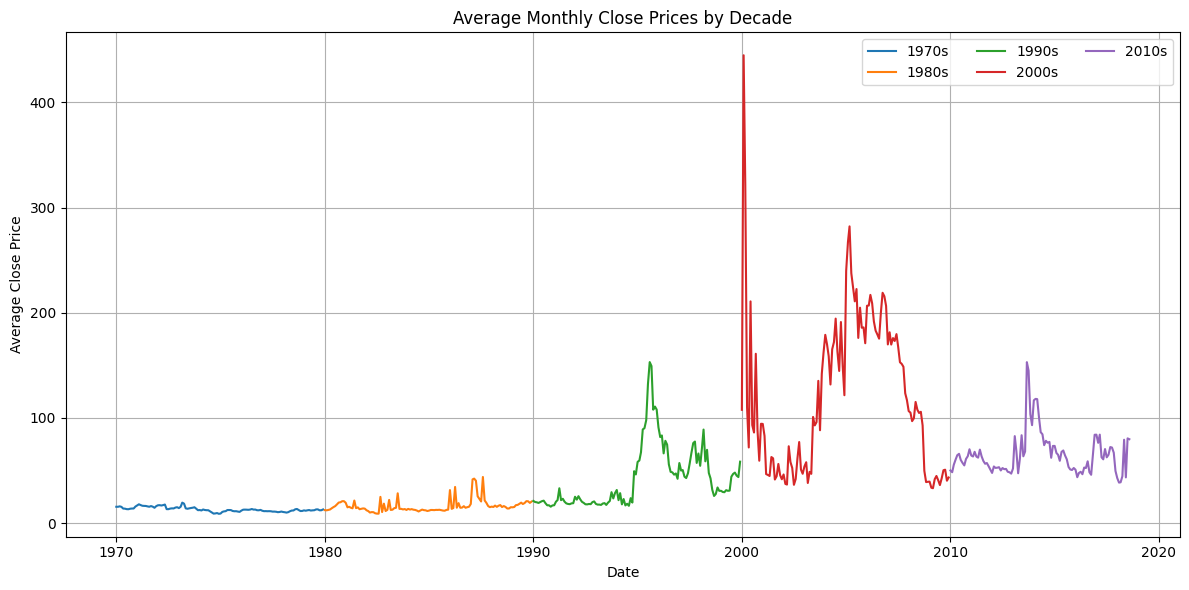

In [32]:
plt.figure(figsize=(12, 6))
for decade, df in full_monthly.groupby('decade'):
    plt.plot(df['month'], df['avg_close'], label=f'{int(decade)}s')

plt.title('Average Monthly Close Prices by Decade')
plt.xlabel('Date')
plt.ylabel('Average Close Price')
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

## 10. Visualization: Volume Distribution by Decade

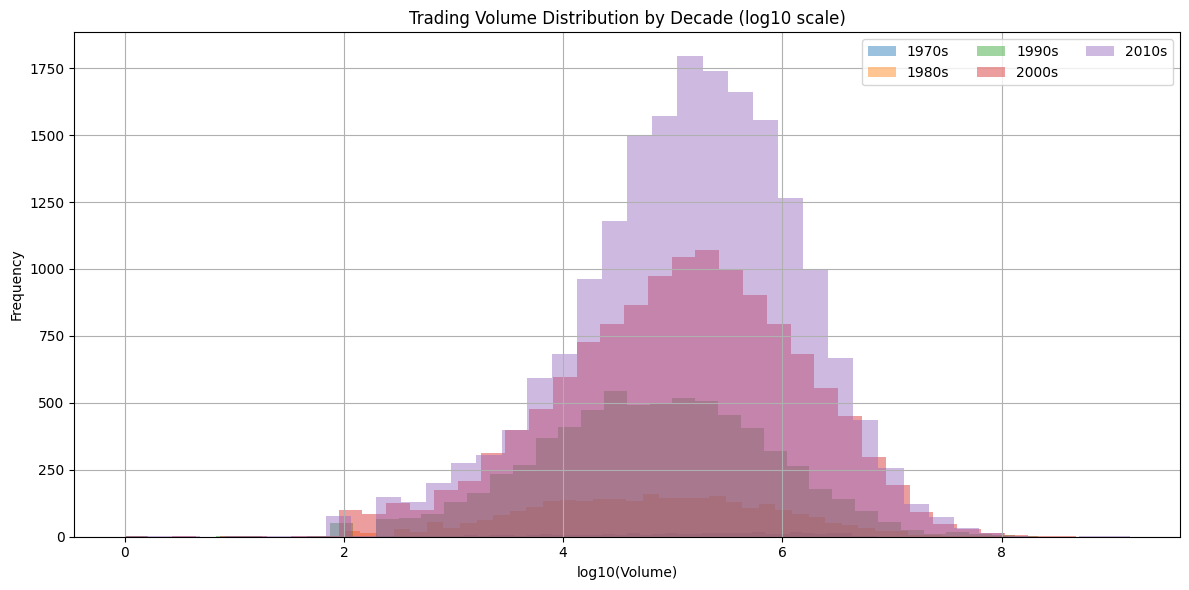

In [33]:
plt.figure(figsize=(12, 6))
for decade, df in visual_data.groupby('decade'):
    volume_log = np.log10(df['volume'].replace(0, np.nan).dropna())
    plt.hist(volume_log, bins=40, alpha=0.45, label=f'{int(decade)}s')

plt.title('Trading Volume Distribution by Decade (log10 scale)')
plt.xlabel('log10(Volume)')
plt.ylabel('Frequency')
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

## 11. Visualization: High-Low Price Spread

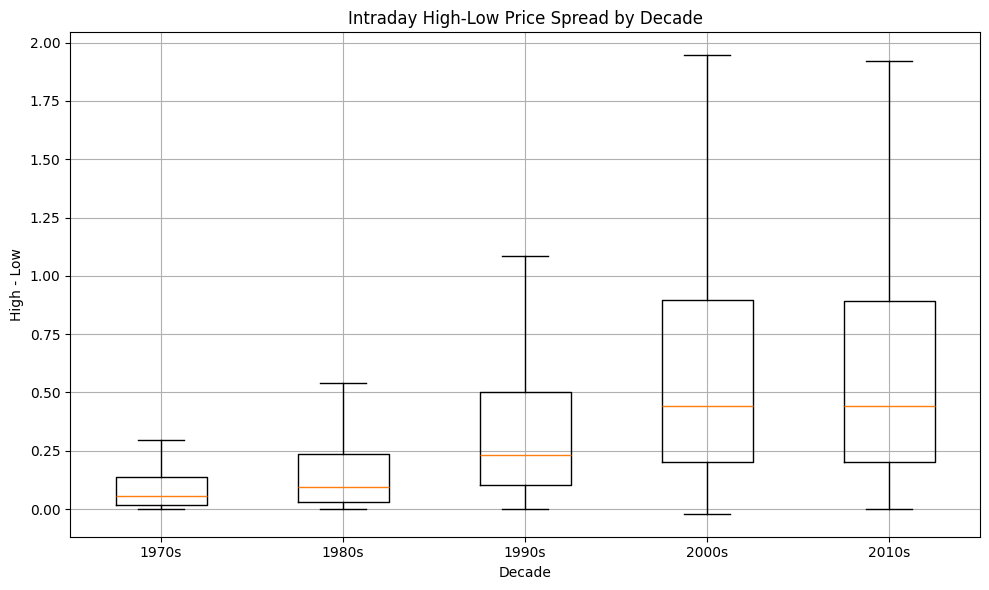

In [34]:
visual_data['high_low_spread'] = visual_data['high'] - visual_data['low']

box_data = []
labels = []
for decade, df in visual_data.groupby('decade'):
    spread = df['high_low_spread'].dropna()
    if len(spread) > 0:
        box_data.append(spread)
        labels.append(f'{int(decade)}s')

plt.figure(figsize=(10, 6))
plt.boxplot(box_data, tick_labels=labels, showfliers=False)
plt.title('Intraday High-Low Price Spread by Decade')
plt.xlabel('Decade')
plt.ylabel('High - Low')
plt.tight_layout()
plt.show()

## 12. Sector-Level EDA

,decade,sector,close,volume
0,1970,BASIC INDUSTRIES,5.740468,4.210692e+05
1,1970,CAPITAL GOODS,19.288825,3.645600e+05
2,1970,CONSUMER DURABLES,5.741978,1.262929e+05
3,1970,CONSUMER NON-DURABLES,1.873100,1.326324e+06
4,1970,CONSUMER SERVICES,4.068982,8.502571e+05
5,1970,ENERGY,3.774053,1.392723e+06
6,1970,FINANCE,2.301721,4.757824e+05
7,1970,HEALTH CARE,3.671875,1.248710e+06
8,1970,MISCELLANEOUS,1.263023,1.132800e+06
9,1970,PUBLIC UTILITIES,13.499764,5.553261e+04


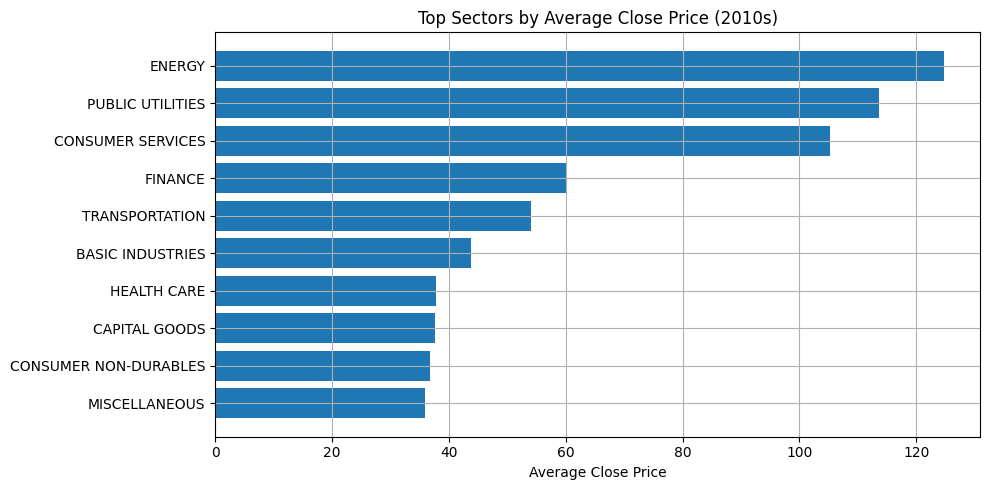

In [35]:
sector_summary = visual_data.groupby(['decade', 'sector'])[['close', 'volume']].mean().reset_index()
display(sector_summary.head(20))

latest_decade = sector_summary['decade'].max()
top_sectors = sector_summary[sector_summary['decade'] == latest_decade].sort_values('close', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_sectors['sector'].fillna('Unknown'), top_sectors['close'])
plt.title(f'Top Sectors by Average Close Price ({int(latest_decade)}s)')
plt.xlabel('Average Close Price')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Findings

1. Stock price behavior changes across decades, so decade-level segmentation is useful.
2. Trading volume is highly skewed, so a log scale is more informative than raw volume.
3. High-low spreads can be used as an initial proxy for intraday volatility.
4. Sector metadata adds business context and helps compare market behavior beyond individual tickers.

## 14. Proposed Hypotheses for Future Analysis

- **H1:** Trading volume increased over time because of electronic trading and wider market access.
- **H2:** Crisis periods are associated with larger high-low spreads.
- **H3:** Sector classification explains part of the variation in prices and volume.
- **H4:** Adjusted close prices are better than raw close prices for long-term return analysis because they account for splits and dividends.